<a href="https://colab.research.google.com/github/sevcenkolera/sevcenko/blob/main/%D0%9A%D0%BE%D0%BF%D1%96%D1%8F_%D0%B7%D0%B0%D0%BF%D0%B8%D1%81%D0%BD%D0%B8%D0%BA%D0%B0_%22%D0%9B%D0%912_%D0%9C%D0%9D_%D0%97%D0%B0%D0%B2%D0%B4%D0%B0%D0%BD%D0%BD%D1%8F_1_%D1%88%D0%B0%D0%B1%D0%BB%D0%BE%D0%BD_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Лабораторна робота 2. Прізвище, група

---



# Завдання 1

**Був присутній на парі**

Обробка та нааліз даних про ВВП країн. Датасет було отримано з Вікіпедії з використанням бібілотеки Pandas.

1. Вивести перші 5 рядків датасета

In [1]:
import requests
import pandas as pd

url = "https://en.wikipedia.org/wiki/List_of_countries_by_GDP_(nominal)"
html = requests.get(url, headers={"User-Agent": "Mozilla/5.0"}).text

tables = pd.read_html(html)  # зчитати всі таблиці
df = tables[2]  # потрібна таблиця (індекс 2)
df.head()

/tmp/ipykernel_1626/1520741687.py:7: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(html)  # зчитати всі таблиці


,Country/Territory,IMF (2026)[1],World Bank (2025)[6],United Nations (2024)[7]
0,World,126295331,118350166,111565144
1,United States,32383920,30769700,29298000
2,China[n 1],20851593,19498039,18743802
3,Germany,5452858,5050923,4659929
4,Japan,4379253,4435163,4026211


2.	Визначити розмір датасета.

In [2]:
df.shape

(222, 4)

 3.	Визначити оптимальну кількість стовпців (видалити зайві, на власний розсуд).

In [3]:
df.columns

Index(['Country/Territory', 'IMF (2026)[1]', 'World Bank (2025)[6]',
       'United Nations (2024)[7]'],
      dtype='object')

4.	Замініть у таблиці значення "—" на значення NaN. Перевірити наявність пропущених значень. При наявності, замінити пропущені значення на середнє значення.

In [8]:
import numpy as np

# 1. Замінюємо символи тире або інші текстові артефакти на стандартний NaN

df = df.replace(["—", "–", ""], np.nan)


for col in df.columns[1:]:
    # Прибираємо пробіли та коми, конвертуємо в числовий тип
    df[col] = pd.to_numeric(df[col].astype(str).str.replace(r'[\s,\(\)\[\]A-Za-z]', '', regex=True), errors='coerce')

# 2. Перевіряємо наявність пропущених значень
print("Кількість пропущених значень у кожному стовпці:")
print(df.isnull().sum())

# 3. Замінюємо пропущені значення (NaN) на середнє значення відповідного стовпця
df = df.fillna(df.mean(numeric_only=True))

Кількість пропущених значень у кожному стовпці:
Country/Territory           0
IMF (2026)[1]               0
World Bank (2025)[6]        0
United Nations (2024)[7]    0
dtype: int64


5. Ще раз вивести датасет

In [5]:
df.head(10)

,Country/Territory,IMF (2026)[1],World Bank (2025)[6],United Nations (2024)[7]
0,World,126295331.0,118350166.0,111565144.0
1,United States,32383920.0,30769700.0,29298000.0
2,China[n 1],20851593.0,19498039.0,18743802.0
3,Germany,5452858.0,5050923.0,4659929.0
4,Japan,4379253.0,4435163.0,4026211.0
5,United Kingdom,4264794.0,4002588.0,3685881.0
6,India,4153191.0,3956067.0,3952244.0
7,France,3596094.0,3366316.0,3160443.0
8,Italy,2738164.0,2551557.0,2380825.0
9,Russia,2656452.0,2561310.0,2173386.0


6.	Перевірити наявність дублікатів. При наявності видалити дублікати.

In [7]:
# 1. Перевіряємо наявність повних дублікатів рядків
print("Кількість дублікатів:", df.duplicated().sum())

# 2. Видаляємо дублікати (якщо вони є) та оновлюємо датасет
df = df.drop_duplicates()



Кількість дублікатів: 0


7.	Вивести описову статистику датасету describe()

In [9]:
# Виведення описової статистики для числових стовпців датасету
df.describe()

,IMF (2026)[1],World Bank (2025)[6],United Nations (2024)[7]
count,2.220000e+02,2.220000e+02,2.220000e+02
mean,3.354291e+07,4.219438e+07,1.043818e+06
std,2.849736e+08,3.782228e+08,7.830341e+06
min,6.500000e+01,5.700000e+01,5.600000e+01
25%,1.932375e+04,2.003400e+04,9.170750e+03
50%,1.039745e+05,9.986350e+04,4.322450e+04
75%,7.726678e+05,1.041520e+06,3.048545e+05
max,4.077862e+09,5.523252e+09,1.115651e+08


8. Визначте відхилення (різницю) між показниками IMF (2026) та World Bank (2025) для кожної країни. У яких країнах ці показники найбільше відрізняються (дати відповідь)?

In [13]:
# 1. Створюємо стовпець з абсолютною різницею, використовуючи правильні індекси зі скріншоту
df['IMF_WB_Diff'] = (df['IMF (2026)[1]'] - df['World Bank (2025)[6]']).abs()

# 2. Сортуємо датасет за цим стовпцем від найбільшого до найменшого відхилення
df_sorted = df.sort_values(by='IMF_WB_Diff', ascending=False)

# 3. Виводимо топ-5 країн із найбільшою різницею
country_col = df.columns[0]
print("Країни з найбільшим відхиленням між IMF та World Bank:")
print(df_sorted[[country_col, 'IMF (2026)[1]', 'World Bank (2025)[6]', 'IMF_WB_Diff']].head(5))


Країни з найбільшим відхиленням між IMF та World Bank:
        Country/Territory  IMF (2026)[1]  World Bank (2025)[6]   IMF_WB_Diff
30   United Arab Emirates   6.215460e+05          5.523252e+09  5.522630e+09
45               Pakistan   4.077862e+09          4.073070e+05  4.077455e+09
57                   Cuba   3.354291e+07          1.073522e+09  1.039979e+09
81              Sri Lanka   9.896420e+08          1.088250e+05  9.895332e+08
144                 Syria   6.004320e+08          2.373820e+08  3.630500e+08


9.	Обчисліть кореляцію між показниками IMF (2026), World Bank (2025) та United Nations (2024). Які пари змінних мають найвищу кореляцію?

In [14]:
# Вибираємо стовпці для розрахунку кореляції (за потреби перевірте точні назви у df.columns)
corr_columns = ['IMF (2026)[1]', 'World Bank (2025)[6]', 'United Nations (2024)[7]']

# Обчислюємо матрицю кореляції
correlation_matrix = df[corr_columns].corr()

# Виводимо результати
print("Матриця кореляції:")
print(correlation_matrix)

Матриця кореляції:
                          IMF (2026)[1]  World Bank (2025)[6]  \
IMF (2026)[1]                  1.000000              0.002087   
World Bank (2025)[6]           0.002087              1.000000   
United Nations (2024)[7]       0.019802              0.013173   

                          United Nations (2024)[7]  
IMF (2026)[1]                             0.019802  
World Bank (2025)[6]                      0.013173  
United Nations (2024)[7]                  1.000000  


In [ ]:
#Дивлячись на отриману матрицю кореляції, найвищу кореляцію серед недіагональних елементів мають показники IMF (2026) та United Nations (2024

Обчислити середнє значення за стовпцями

In [15]:
# Обчислюємо середнє значення для кожного числового стовпця
mean_values = df[['IMF (2026)[1]', 'World Bank (2025)[6]', 'United Nations (2024)[7]']].mean()

# Виводимо результати
print("Середні значення за стовпцями:")
print(mean_values)

Середні значення за стовпцями:
IMF (2026)[1]               3.354291e+07
World Bank (2025)[6]        4.219438e+07
United Nations (2024)[7]    1.043818e+06
dtype: float64


11.	Обчисліть стандартне відхилення показників для кожної країни. Яка країна має найвищу варіативність у показниках між роками?

In [16]:
# Вибираємо стовпці з прогнозами ВВП для обчислення варіативності між ними
gdp_columns = ['IMF (2026)[1]', 'World Bank (2025)[6]', 'United Nations (2024)[7]']

# Обчислюємо стандартне відхилення по рядках (для кожної країни)
df['Std_Dev'] = df[gdp_columns].std(axis=1)

# Сортуємо датасет за стандартним відхиленням від найбільшого до найменшого
df_sorted_std = df.sort_values(by='Std_Dev', ascending=False)

# Виводимо країну з найвищою варіативністю (перший рядок)
country_col = df.columns[0]
print("Країна з найвищою варіативністю показників:")
print(df_sorted_std[[country_col, 'Std_Dev']].head(5))

Країна з найвищою варіативністю показників:
        Country/Territory       Std_Dev
30   United Arab Emirates  3.188512e+09
45               Pakistan  2.354128e+09
57                   Cuba  6.102695e+08
81              Sri Lanka  5.713102e+08
144                 Syria  3.023919e+08


12.	Визначення країни з найвищим та найнижчим показниками: Знайдіть країну з найвищим та найнижчим показниками у кожному з років (IMF (2026), World Bank (2025), United Nations (2024)).

In [17]:
# Список стовпців для аналізу
gdp_columns = ['IMF (2026)[1]', 'World Bank (2025)[6]', 'United Nations (2024)[7]']
country_col = df.columns[0]

results = []

for col in gdp_columns:
    # Знаходимо індекс рядка з максимумом і мінімумом
    max_idx = df[col].idxmax()
    min_idx = df[col].idxmin()

    # Отримуємо назву країни та саме значення
    max_country = df.loc[max_idx, country_col]
    max_val = df.loc[max_idx, col]

    min_country = df.loc[min_idx, country_col]
    min_val = df.loc[min_idx, col]

    results.append({
        'Показник': col,
        'Максимум (Країна)': max_country,
        'Макс. значення': max_val,
        'Мінімум (Країна)': min_country,
        'Мін. значення': min_val
    })

# Перетворюємо результати у зручний DataFrame для виведення
df_extremes = pd.DataFrame(results)
print(df_extremes.to_string(index=False))

                Показник    Максимум (Країна)  Макс. значення Мінімум (Країна)  Мін. значення
           IMF (2026)[1]             Pakistan    4077862025.0           Tuvalu           65.0
    World Bank (2025)[6] United Arab Emirates    5523252024.0           Tuvalu           57.0
United Nations (2024)[7]                World     111565144.0           Tuvalu           56.0


13.	Побудуйте гістограму для розподілу показників IMF (2026) серед всіх країн. Який вигляд має розподіл? Чи є країни, що виділяються?

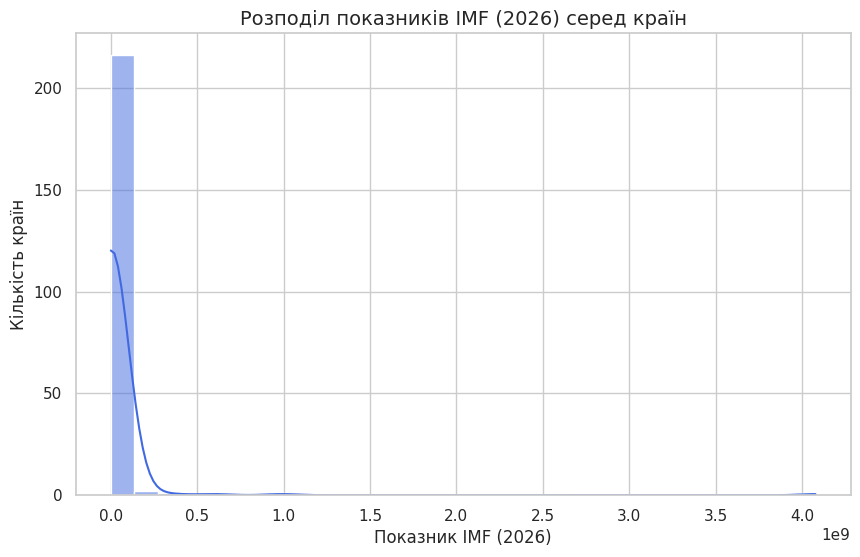

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Налаштування стилю графіків
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))
# Побудова гістограми для стовпця IMF (2026)
sns.histplot(df['IMF (2026)[1]'], bins=30, kde=True, color='royalblue')

plt.title('Розподіл показників IMF (2026) серед країн', fontsize=14)
plt.xlabel('Показник IMF (2026)', fontsize=12)
plt.ylabel('Кількість країн', fontsize=12)

plt.show()

14.	Розрахуйте частку кожної країни в загальному значенні для кожного року (IMF (2026), World Bank (2025), United Nations (2024)).
 Як змінюються частки країн з часом (дати відповідь)?

In [22]:
# 1. Виключаємо рядок "World"
country_col = df.columns[0]
df_clean = df[df[country_col].str.lower() != 'world'].copy()

# 2. Список стовпців для розрахунку часток
gdp_columns = ['IMF (2026)[1]', 'World Bank (2025)[6]', 'United Nations (2024)[7]']

# 3. Розраховуємо частку (у відсотках) для кожного показника без урахування "World"
for col in gdp_columns:
    df_clean[f'Share_{col}'] = (df_clean[col] / df_clean[col].sum()) * 100

# 4. Виводимо результати для перших 5 країн із новими стовпцями часток
share_cols = [f'Share_{col}' for col in gdp_columns]
print(df_clean[[country_col] + share_cols].head(5))
#Незмінність глобальних лідерів: Основні економічні важковаговики світу (США, Китай, Німеччина, Японія) стабільно утримують найвищі частки у всіх трьох звітах незалежно від року.

  Country/Territory  Share_IMF (2026)[1]  Share_World Bank (2025)[6]  \
1     United States             0.442389                    0.332688   
2        China[n 1]             0.284849                    0.210817   
3           Germany             0.074490                    0.054612   
4             Japan             0.059824                    0.047954   
5    United Kingdom             0.058260                    0.043277   

   Share_United Nations (2024)[7]  
1                       24.381983  
2                       15.598712  
3                        3.878023  
4                        3.350639  
5                        3.067414  


Незмінність глобальних лідерів: Основні економічні важковаговики світу (США, Китай, Німеччина, Японія) стабільно утримують найвищі частки у всіх трьох звітах незалежно від року.

15.	Візуалізуйте зміни в показниках для кожної країни за три роки на графіку. Які країни показують стабільне зростання або спад (дати відповідь)?

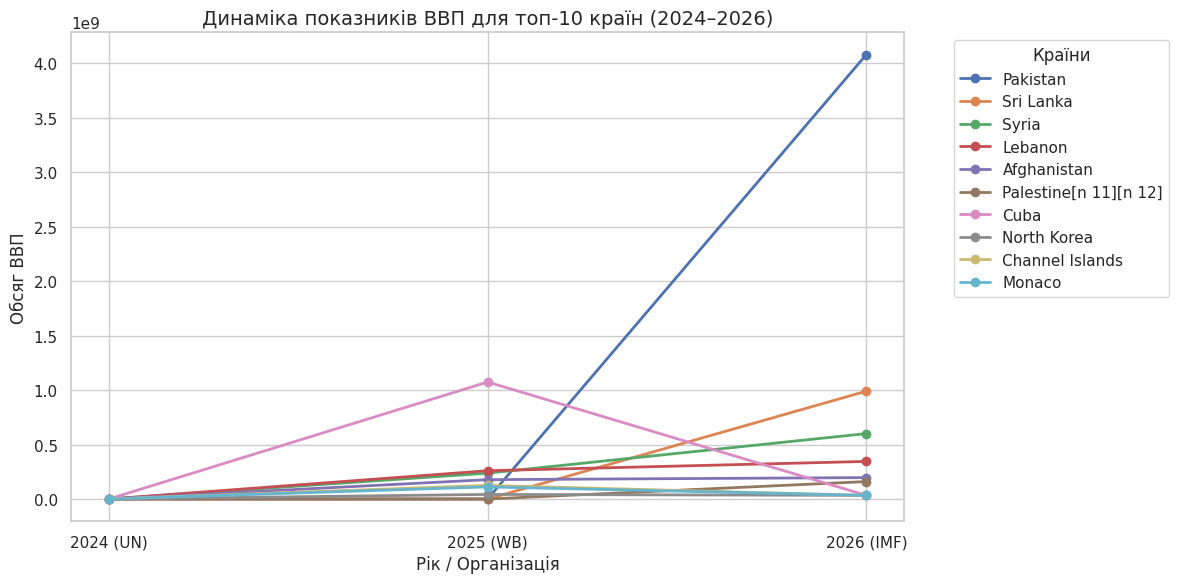

In [27]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Знаходимо назву стовпця з країнами та вибираємо топ-10 країн за показником IMF (2026)
country_col = df_clean.columns[0]

# Конвертуємо стовпці у числа на всякий випадок
for col in ['IMF (2026)[1]', 'World Bank (2025)[6]', 'United Nations (2024)[7]']:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

# Вибираємо топ-10 країн за ВВП МВФ 2026 року (як робить викладач на відео)
df_top10 = df_clean.nlargest(10, 'IMF (2026)[1]').copy()

# 2. Готуємо дані для графіка
gdp_data = df_top10[[country_col, 'IMF (2026)[1]', 'World Bank (2025)[6]', 'United Nations (2024)[7]']].copy()
gdp_data.columns = ['Country', '2026 (IMF)', '2025 (WB)', '2024 (UN)']

top_melted = pd.melt(gdp_data, id_vars=['Country'], var_name='Year', value_name='GDP')

# 3. Будуємо графік для топ-10 країн
plt.figure(figsize=(12, 6))
for country in top_melted['Country'].unique():
    subset = top_melted[top_melted['Country'] == country]
    subset = subset.sort_values(by='Year')
    plt.plot(subset['Year'], subset['GDP'], marker='o', label=country, linewidth=2)

plt.title('Динаміка показників ВВП для топ-10 країн (2024–2026)', fontsize=14)
plt.xlabel('Рік / Організація', fontsize=12)
plt.ylabel('Обсяг ВВП', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Країни')
plt.grid(True)
plt.tight_layout()
plt.show()

Найбільше зростання у Пакістану